# **Cargar las librerias**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import zipfile
import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# **Descargar y preparar los datos (Dogs vs Cats)**

In [6]:
# Descargar el dataset desde Kaggle
!wget https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip

# Descomprimir
with zipfile.ZipFile('cats_and_dogs_filtered.zip', 'r') as zip_ref:
    zip_ref.extractall()

base_dir = 'cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

--2025-06-29 03:08:06--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.217.207, 172.217.204.207, 172.217.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.217.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘cats_and_dogs_filtered.zip.1’

cats_and_dogs_filte 100%[===================>]  65.43M   235MB/s    in 0.3s    

2025-06-29 03:08:06 (235 MB/s) - ‘cats_and_dogs_filtered.zip.1’ saved [68606236/68606236]



# **Normalización con ImageDataGenerator**

In [7]:
# Preprocesamiento con el mismo esquema de MobileNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


# **Verificamos algunas imágenes**

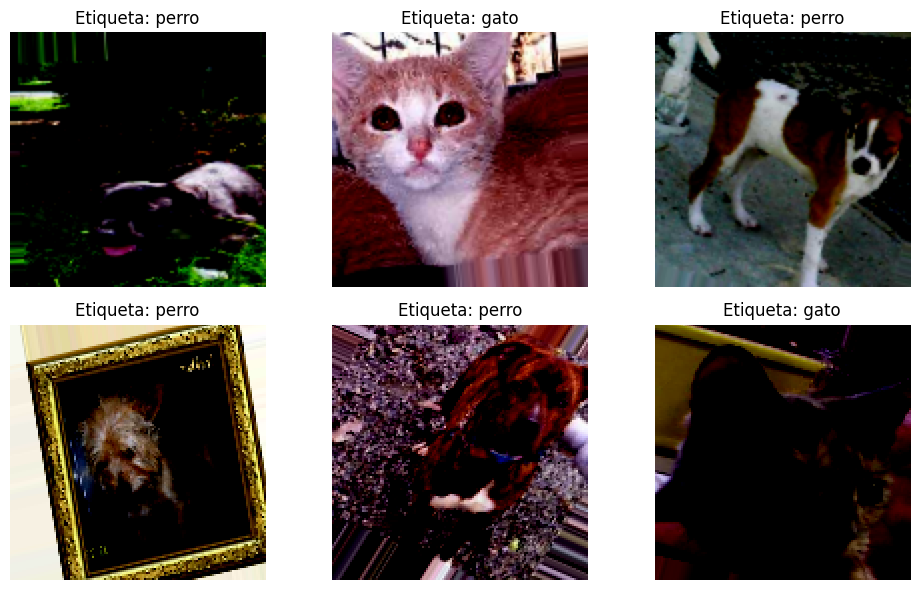

In [8]:
class_names = ['gato', 'perro']
images, labels = next(train_generator)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Etiqueta: {class_names[int(labels[i])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# **Desarrollo e Implementación del Modelo CNN**

In [9]:
# IMPLEMENTACIÓN DEL MODELO CNN CON TRANSFER LEARNING

from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Moved to an earlier cell
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Cargar MobileNetV2 sin la capa superior (head), solo como extractor de características
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Congelar la base

# Construir modelo CNN encima de MobileNetV2
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Salida binaria
])

# Compilar el modelo
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,621,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,879,681 (18.61 MB)

 Trainable params: 2,621,697 (10.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Entrenamiento del modelo**

In [10]:
# Entrenamiento
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8480 - loss: 0.3472

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 360ms/step - accuracy: 0.8491 - loss: 0.3450 - val_accuracy: 0.9700 - val_loss: 0.0782
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.9631 - loss: 0.0986 - val_accuracy: 0.9770 - val_loss: 0.0715
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step - accuracy: 0.9483 - loss: 0.1238 - val_accuracy: 0.9730 - val_loss: 0.0744
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.9576 - loss: 0.1058 - val_accuracy: 0.9800 - val_loss: 0.0662
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.9696 - loss: 0.0826 - val_accuracy: 0.9790 - val_loss: 0.0655
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.9753 - loss: 0.0696 - val_accuracy: 0.9660 - val_loss: 0.0850
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.9716 - loss: 0.0796 - val_accuracy: 0.9720 - val_loss: 0.0717
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.9771 - loss: 0.0732 - val_accuracy: 0.978

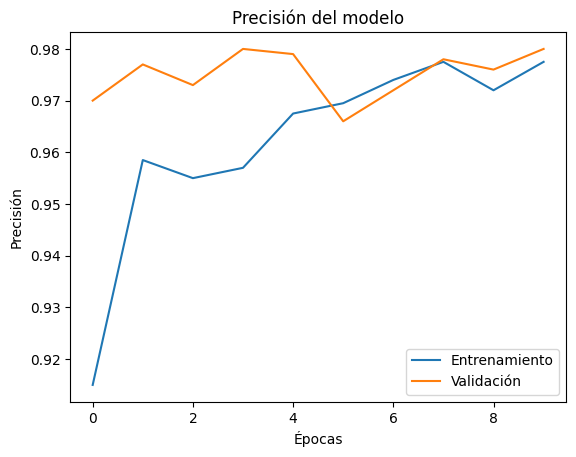

In [11]:
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step


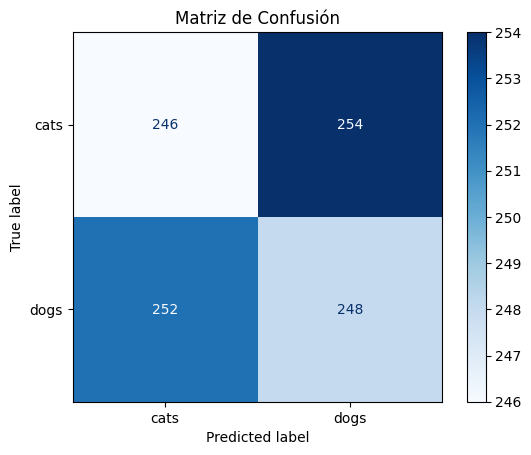

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Paso 1: Obtener etiquetas verdaderas e imágenes
val_generator.reset()
Y_true = val_generator.classes
Y_pred_prob = model.predict(val_generator, verbose=1)
Y_pred = (Y_pred_prob > 0.5).astype(int).reshape(-1)

# Paso 2: Crear matriz de confusión
cm = confusion_matrix(Y_true, Y_pred)
labels = list(val_generator.class_indices.keys())

# Paso 3: Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

In [13]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Subir archivo
uploaded = files.upload()

Saving GATO.webp to GATO.webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
🐱 Es un gato


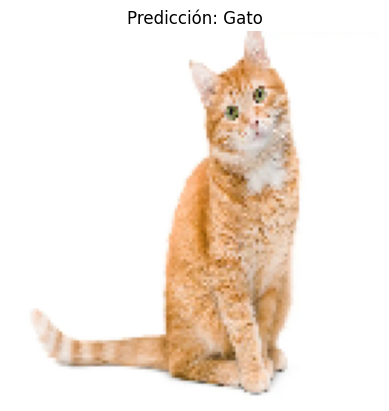

In [14]:
# Obtener el nombre del archivo subido
file_name = list(uploaded.keys())[0]

# Cargar y preprocesar imagen
img_path = file_name
img = image.load_img(img_path, target_size=(128, 128))  # mismo tamaño que usó el modelo
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Realizar predicción
prediction = model.predict(img_array)

# Interpretar resultado
if prediction[0] > 0.5:
    print("🐶 Es un perro")
else:
    print("🐱 Es un gato")

# Mostrar imagen
plt.imshow(img)
plt.axis('off')
plt.title("Predicción: " + ("Perro" if prediction[0] > 0.5 else "Gato"))
plt.show()